In [1]:
  # Project 1: Superstore Sales Analysis

from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [2]:
# ================================================
# Project 1: Superstore Sales Analysis
# Analyst: Komal Bramhaji Jondhale
# Date: May 2026
# Goal: Identify key business insights from
#       10,000 orders across 4 US regions
# ================================================

import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")
print("Dataset loaded:", df.shape)

Dataset loaded: (9994, 21)


In [3]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
#Q1: Which region generates the most revenue but has the lowest profit margin?

#total Sales per Region
df.groupby('Region')['Sales'].sum()

#total Profit per Region?
df.groupby('Region')['Profit'].sum()

#combine them into one table
region_summary = df.groupby('Region')[['Sales', 'Profit']].sum()

#Then add a Profit Margin column
region_summary['Profit_Margin'] = (region_summary['Profit'] / region_summary['Sales']) * 100

In [5]:
print(region_summary.sort_values('Sales', ascending=False))


               Sales       Profit  Profit_Margin
Region                                          
West     725457.8245  108418.4489      14.944831
East     678781.2400   91522.7800      13.483399
Central  501239.8908   39706.3625       7.921629
South    391721.9050   46749.4303      11.934342


In [6]:
# INSIGHT: West generates the most revenue ($725K) but Central has the
# lowest profit margin at only 7.9% despite being 3rd in sales.
# Central region needs immediate attention.

In [7]:
#Q2: Which 3 sub-categories are losing money overall?
df.groupby('Sub-Category')['Profit'].sum().sort_values().head(3)

,Profit
Sub-Category,
Tables,-17725.4811
Bookcases,-3472.5560
Supplies,-1189.0995


In [8]:
# INSIGHT: Tables, Bookcases and Supplies are all losing money.
# Tables alone lost $17,725 — the business should review
# pricing or discontinue these sub-categories.

In [9]:
#Q3: Does higher discount lead to more loss? Show average profit grouped by Discount.


In [10]:
df.groupby('Discount')['Profit'].mean()

,Profit
Discount,
0.00,66.900292
0.10,96.055074
0.15,27.288298
0.20,24.702572
0.30,-45.679636
0.32,-88.560656
0.40,-111.927429
0.45,-226.646464
0.50,-310.703456


In [11]:
# INSIGHT: Clear pattern — discounts above 0.20 (20%) lead to negative
# profit. The 0.50 discount level loses an average of $310 per order.
# Business should cap discounts at 20% maximum.

In [12]:
#Q4: Which customer segment has highest total Sales AND Profit?
df.groupby('Segment')[['Sales','Profit']].sum().sort_values('Sales', ascending=False)

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


In [13]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [14]:
# INSIGHT: Consumer segment leads in both Sales ($1.16M) and Profit ($134K).
# It represents the most valuable customer group —
# marketing should prioritize retaining Consumer segment customers.

In [15]:
#Q5: Which category ships fastest? (hint from earlier — use pd.to_datetime and calculate days to ship)


In [16]:
df['Order_Date'] = pd.to_datetime(df['Order Date'])
df['Ship_Date'] = pd.to_datetime(df['Ship Date'])
df['Days_to_Ship'] = (df['Ship_Date'] - df['Order_Date']).dt.days

In [17]:
df.groupby('Category')['Days_to_Ship'].mean().sort_values()

,Days_to_Ship
Category,
Furniture,3.92
Technology,3.92
Office Supplies,3.98


In [18]:
# INSIGHT: All categories ship at nearly the same speed (3.92 - 3.98 days).
# Shipping is consistent across categories — no bottlenecks identified.

In [19]:
# Visualizations: Turning insights into charts
# ================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look professional
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

/tmp/ipykernel_10723/2357090215.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette='Blues_d')


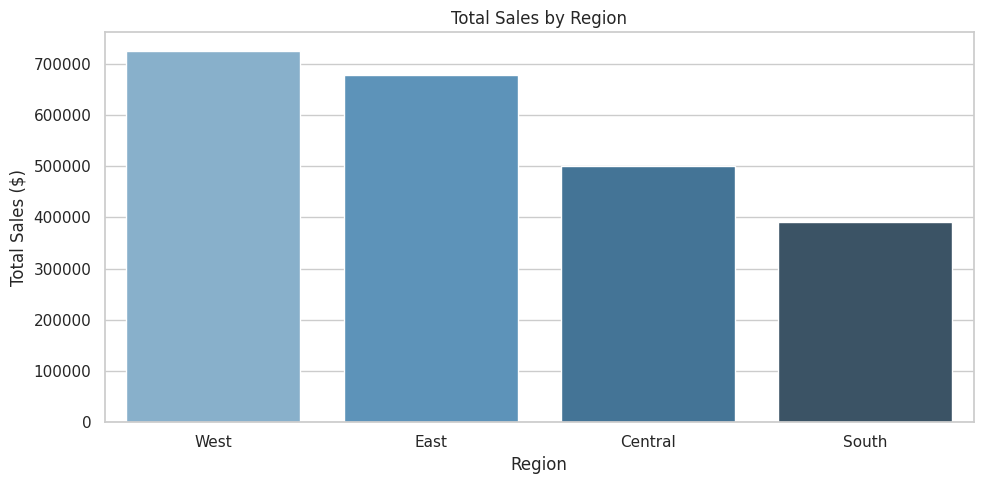

In [20]:
#Chart 1 — Bar chart: Total Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure()
sns.barplot(x=region_sales.index, y=region_sales.values, palette='Blues_d')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

In [21]:
# Chart 2 — Sub-category losses (horizontal bar chart)
# Plot total profit per sub-category, sorted lowest to highest. Show all sub-categories. Use palette='Reds_d'.
# Hint — horizontal bar chart uses x=values, y=index instead of x=index, y=values.

/tmp/ipykernel_10723/1758391483.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subcat_profit.values, y=subcat_profit.index, palette='Reds_d')


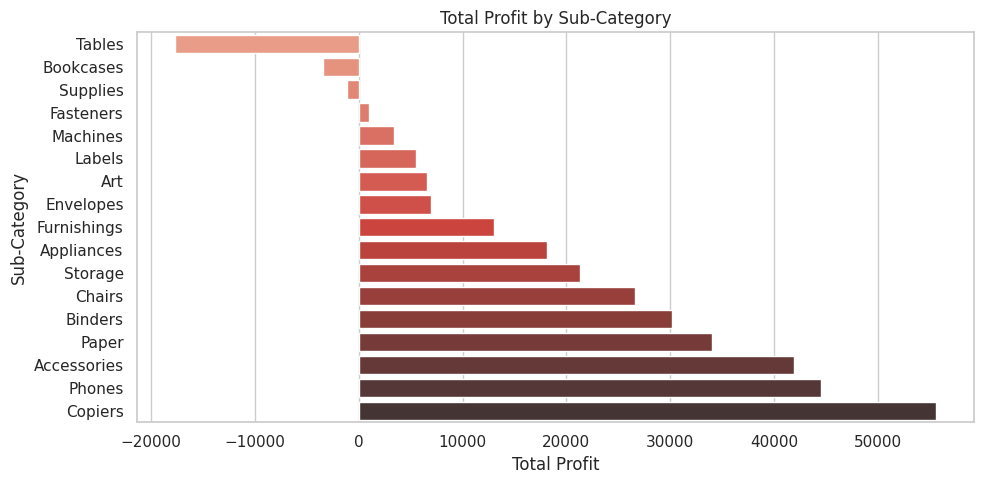

In [23]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
plt.figure()
sns.barplot(x=subcat_profit.values, y=subcat_profit.index, palette='Reds_d')
plt.title('Total Profit by Sub-Category')
plt.xlabel('Total Profit')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

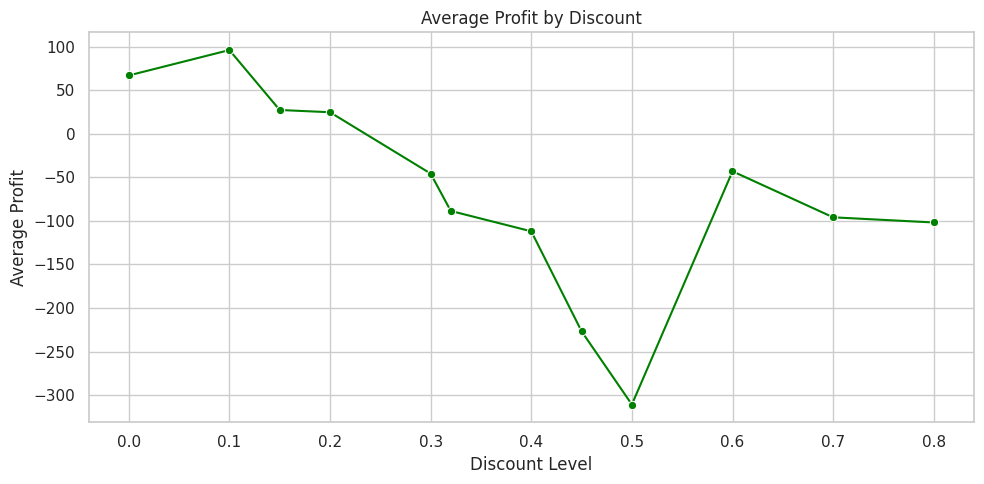

In [24]:
#Chart 3 — Discount vs Profit (line chart)
# Plot average profit per discount level.


In [21]:
# Chart 4 — Segment Sales pie chart

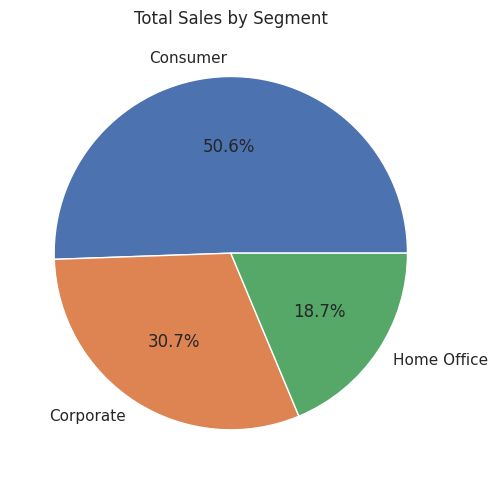

In [25]:
segment_sales = df.groupby('Segment')['Sales'].sum()
plt.figure()
plt.pie(segment_sales, labels=segment_sales.index,autopct='%1.1f%%')
plt.title('Total Sales by Segment')
plt.tight_layout()
plt.show()

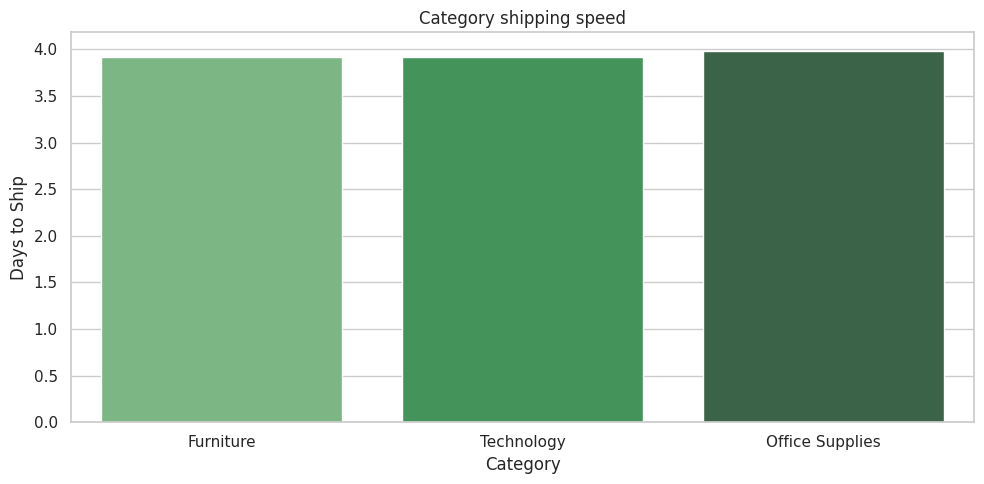

In [26]:
# Chart 5 — Category shipping speed.
Cat_shipping_speed= df.groupby('Category')['Days_to_Ship'].mean().sort_values()
plt.figure()
sns.barplot(x=Cat_shipping_speed.index, y=Cat_shipping_speed.values, hue=Cat_shipping_speed.index, palette='Greens_d', legend=False)
plt.title('Category shipping speed')
plt.xlabel('Category')
plt.ylabel('Days to Ship')
plt.tight_layout()
plt.show()